In [1]:
import polars as pl
import matplotlib.pyplot as plt
%matplotlib inline

from tqdm.notebook import trange

from most_popular import MostPopularConfig, load_and_build, MostPopular, evaluate

# Base-line проекта

Получим ориентир, который должны будут перекрыть другие модели проекта. Будем действовать максимально просто, отдавать еще не просмотренные топ-К популярных за период тренировки как рекомендация для следующего просмотра.

Попутно оценим влияние глобального тренда на метрики.

In [2]:
result = []

for week in trange(0, 25):
    cfg = MostPopularConfig(
        data_dir="../data/raw/VK-LSVD/subsamples/up0.001_ip0.001",
        start_week=0,
        end_week=week,
        min_timespent_pos=5,
        k=10,
    )
    bundle = load_and_build(cfg)
    model = MostPopular(bundle.popularity, bundle.item_ranking)
    metrics = evaluate(model, bundle, k=cfg.k)
    metrics["users"] = bundle.n_users
    metrics["items"] = bundle.n_items
    metrics["val_users"] = len(bundle.val_user_idxs)
    metrics["start_week"] = 0
    metrics["end_week"] = week
    metrics["val_week"] = week + 1
    result.append(metrics)

  0%|          | 0/25 [00:00<?, ?it/s]

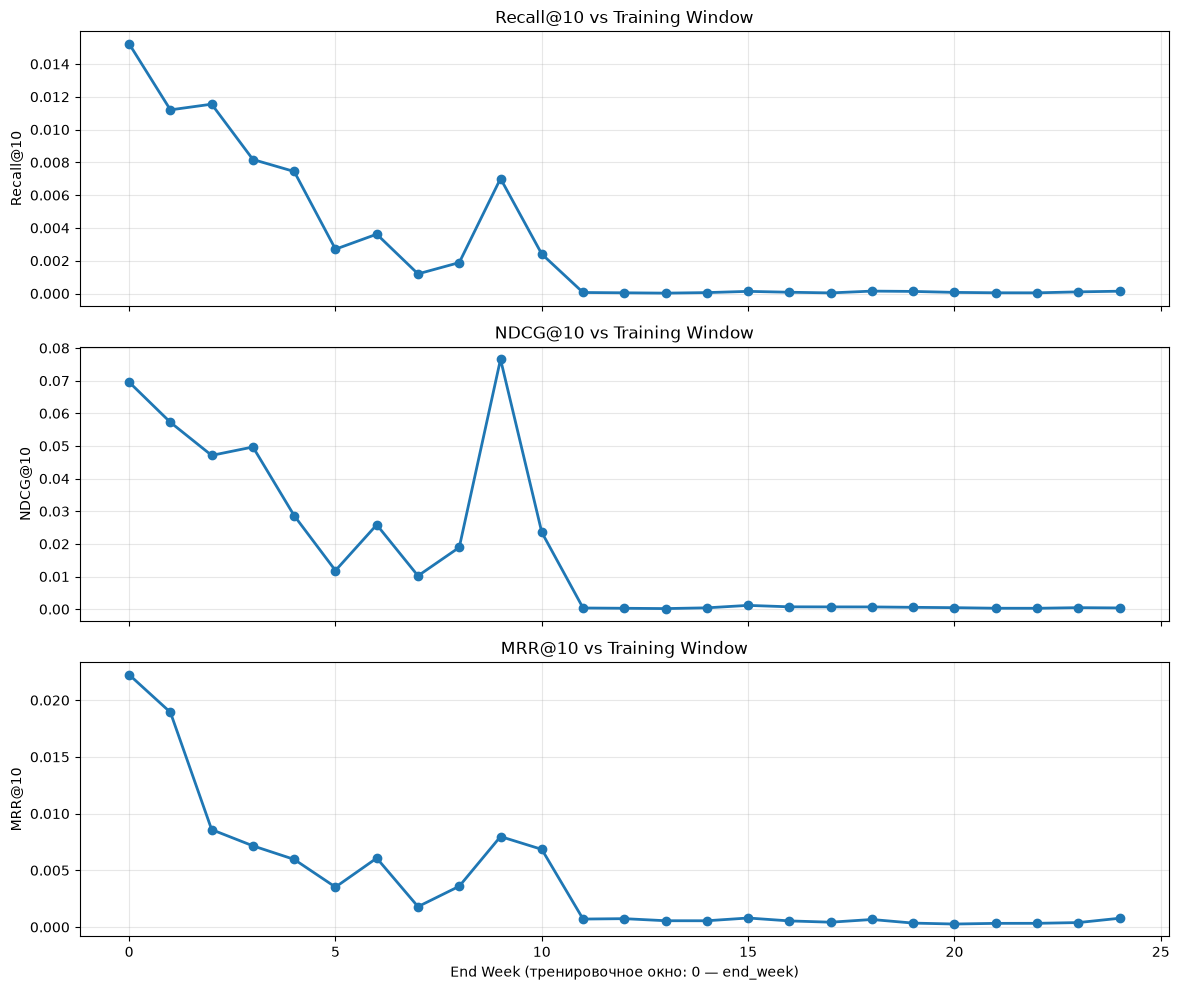

In [3]:
df = pl.DataFrame(result)
df = df.sort('end_week')

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

metrics = ['recall@10', 'ndcg@10', 'mrr@10']
titles = ['Recall@10', 'NDCG@10', 'MRR@10']

for ax, metric, title in zip(axes, metrics, titles):
    ax.plot(df['end_week'], df[metric], marker='o', linewidth=2)
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{title} vs Training Window')

axes[-1].set_xlabel('End Week (тренировочное окно: 0 — end_week)')
plt.tight_layout()
plt.savefig('most_popular_metrics.png', dpi=150)
plt.show()

## Итог

Видим, что с увеличением размера окна метрики падают. Это позволяет однозначно утверждать об отсутствии сквозных предпочтений пользователей, и размер истории более чем в одну - две недели не только бесполезен, но и вреден для точности прогноза.